In [7]:
from mapanything.distill.help_me.dataset_dataloader import TeacherFeatureExtractor
import torch
import numpy as np
from PIL import Image

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

In [6]:
print(f"[INFO] Preparing teacher feature extractor...")
teacher_extractor = None

teacher_extractor = TeacherFeatureExtractor(
    checkpoint_path="/scratch2/nico/sam2/checkpoints/sam2.1_hiera_large.pt",
    device=str(device),
)
teacher_extractor.to(device)

[INFO] Preparing teacher feature extractor...
[INFO] Loading SAM2 checkpoint for teacher feature extractor
[INFO] Loaded SAM2 feature extractor on cuda


In [8]:
pil_images = []

# specific image path
image_path = "/scratch2/nico/distillation/dataset/blendedmbs_picked/overfit/action_figure/00000000.jpg"
img_pil_in = Image.open(image_path).convert("RGB")
img_np_in = np.array(img_pil_in)  # H, W, 3

# tensor (C, H, W) in [0,1], with batch dim
img_tensor = torch.from_numpy(img_np_in).permute(2, 0, 1).float() / 255.0
if img_tensor.dim() == 3:
    img_tensor = img_tensor.unsqueeze(0)  # (1,3,H,W)

batch_idx = 0
img_single = img_tensor[batch_idx]  # (3, H, W)
img_np = (img_single.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
img_pil = Image.fromarray(img_np)
pil_images.append(img_pil)

In [9]:
with torch.no_grad():
            teacher_features = teacher_extractor(pil_images).to(device, non_blocking=True)

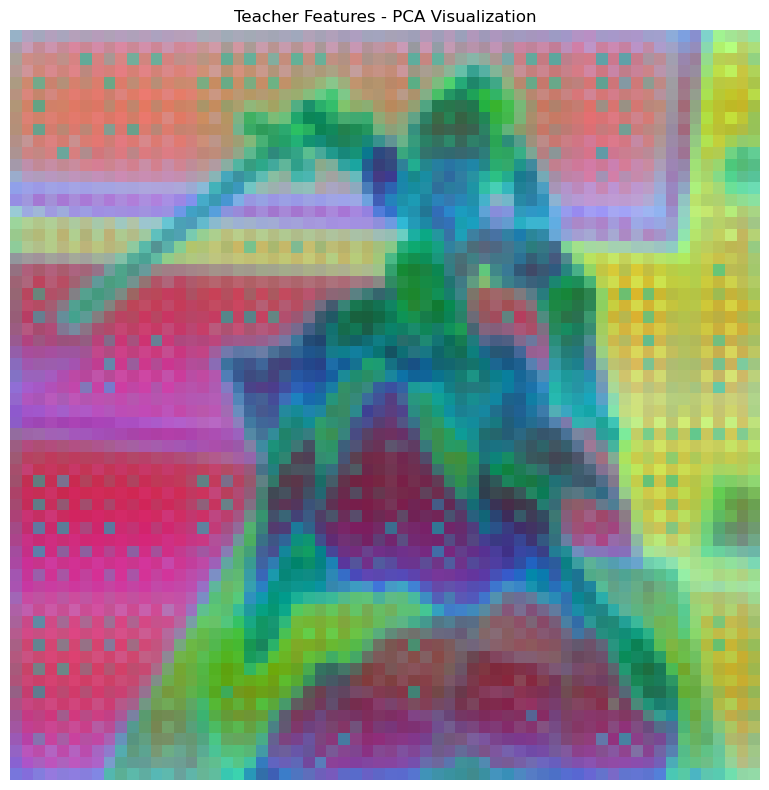

[INFO] PCA explained variance ratio: [0.12307721 0.08428023 0.05409386]
[INFO] Total variance explained: 0.2615


In [10]:
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Reshape teacher_features from (1, C, H, W) to (C, H*W) for PCA
batch_size, channels, height, width = teacher_features.shape
features_reshaped = teacher_features[0].reshape(channels, -1).cpu().numpy()  # (C, H*W)

# Apply PCA to reduce to 3 components for visualization
pca = PCA(n_components=3)
features_pca = pca.fit_transform(features_reshaped.T)  # (H*W, 3)

# Reshape back to spatial dimensions
pca_image = features_pca.reshape(height, width, 3)

# Normalize to [0, 1] for visualization
pca_image = (pca_image - pca_image.min()) / (pca_image.max() - pca_image.min())

# Display
plt.figure(figsize=(10, 8))
plt.imshow(pca_image)
plt.title("Teacher Features - PCA Visualization")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"[INFO] PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"[INFO] Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

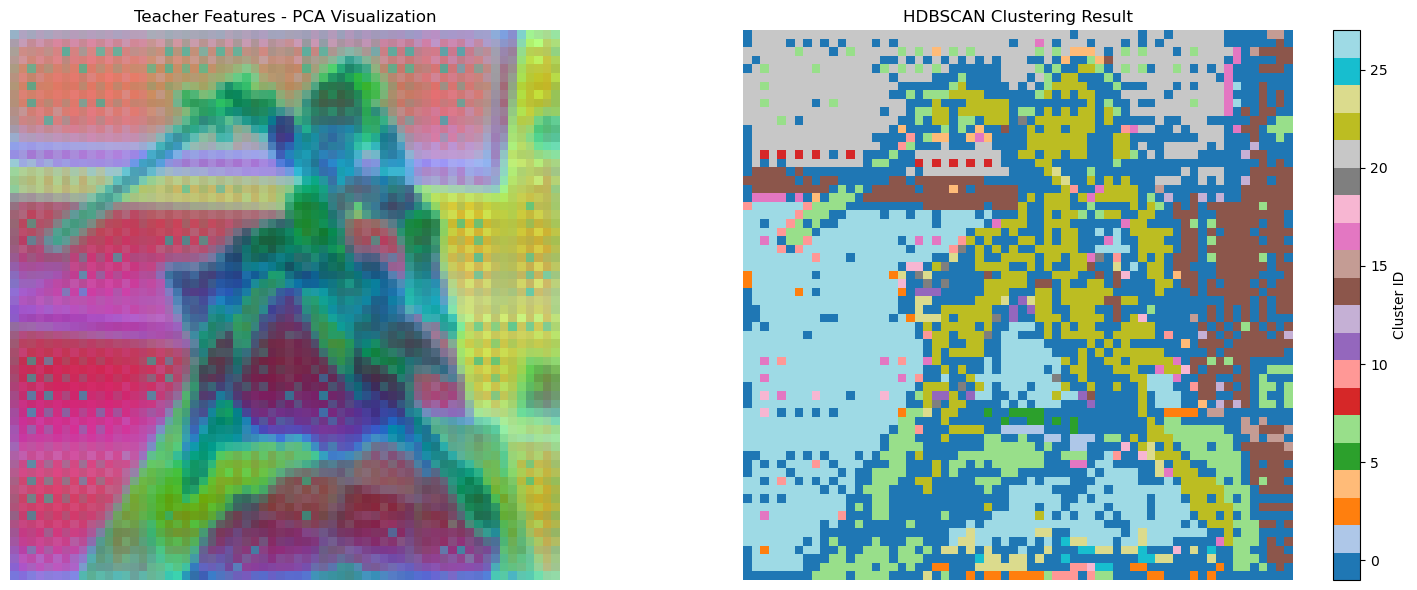

[INFO] Number of clusters found: 28
[INFO] Number of noise points: 1425


In [11]:
from sklearn.cluster import HDBSCAN

import matplotlib.pyplot as plt

# Cluster the PCA features with HDBSCAN
clusterer = HDBSCAN(min_cluster_size=10, min_samples=5)
labels = clusterer.fit_predict(features_pca)

# Reshape labels back to spatial dimensions
cluster_map = labels.reshape(height, width)

# Display the clustering result
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original PCA visualization
axes[0].imshow(pca_image)
axes[0].set_title("Teacher Features - PCA Visualization")
axes[0].axis('off')

# HDBSCAN clustering result
im = axes[1].imshow(cluster_map, cmap='tab20')
axes[1].set_title("HDBSCAN Clustering Result")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='Cluster ID')

plt.tight_layout()
plt.show()

print(f"[INFO] Number of clusters found: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"[INFO] Number of noise points: {list(labels).count(-1)}")

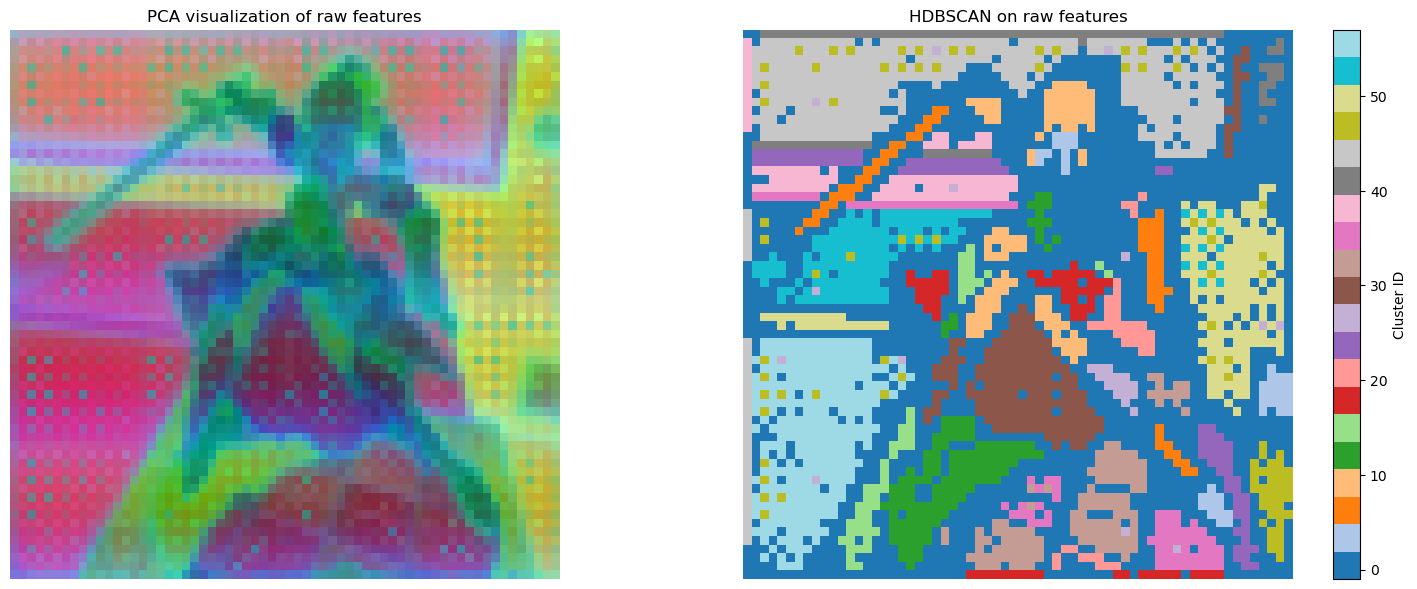

[INFO] Number of clusters found: 58
[INFO] Number of noise points: 1740
[INFO] PCA explained variance ratio: [0.12307721 0.08428023 0.05409386]
[INFO] Total variance explained: 0.2615


In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN

import matplotlib.pyplot as plt

# Raw features: (H*W, C)
X_raw = features_reshaped.T

# HDBSCAN directly on raw features
clusterer_raw = HDBSCAN(min_cluster_size=10, min_samples=5)
labels_raw = clusterer_raw.fit_predict(X_raw)

# PCA only for visualization
pca_raw = PCA(n_components=3)
features_pca_raw = pca_raw.fit_transform(X_raw)
pca_image_raw = features_pca_raw.reshape(height, width, 3)

# Normalize PCA image to [0, 1]
pca_image_raw = (pca_image_raw - pca_image_raw.min()) / (pca_image_raw.max() - pca_image_raw.min())

# Reshape labels to spatial map
cluster_map_raw = labels_raw.reshape(height, width)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(pca_image_raw)
axes[0].set_title("PCA visualization of raw features")
axes[0].axis("off")

im = axes[1].imshow(cluster_map_raw, cmap="tab20")
axes[1].set_title("HDBSCAN on raw features")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="Cluster ID")

plt.tight_layout()
plt.show()

print(f"[INFO] Number of clusters found: {len(set(labels_raw)) - (1 if -1 in labels_raw else 0)}")
print(f"[INFO] Number of noise points: {list(labels_raw).count(-1)}")
print(f"[INFO] PCA explained variance ratio: {pca_raw.explained_variance_ratio_}")
print(f"[INFO] Total variance explained: {pca_raw.explained_variance_ratio_.sum():.4f}")

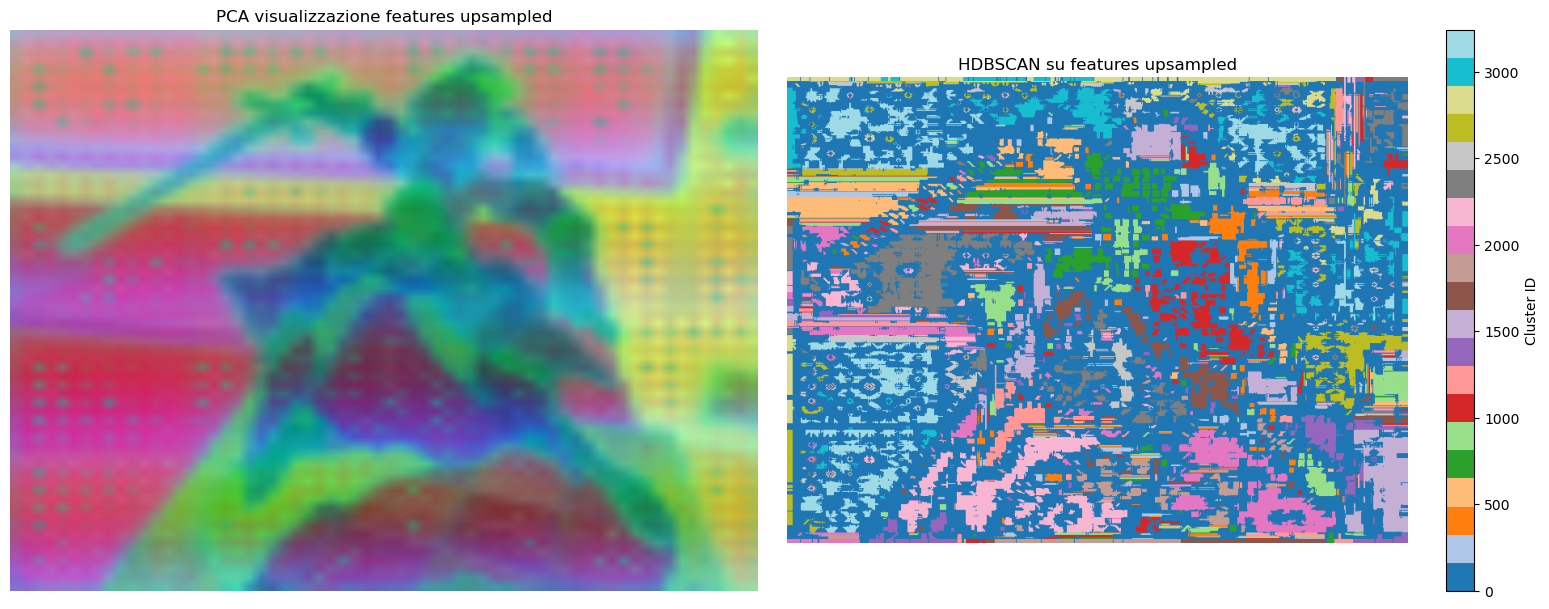

[INFO] Number of clusters found: 3245
[INFO] Number of noise points: 243629
[INFO] PCA explained variance ratio: [0.14429756 0.0992069  0.06345733]
[INFO] Total variance explained: 0.3070


In [13]:
import matplotlib.pyplot as plt

# Upsample teacher features to the original image resolution
orig_height, orig_width = img_np_in.shape[:2]

teacher_features_up = torch.nn.functional.interpolate(
    teacher_features,
    size=(orig_height, orig_width),
    mode="bilinear",
    align_corners=False,
)

# (H*W, C) for clustering / PCA
X_up = teacher_features_up[0].permute(1, 2, 0).reshape(-1, channels).cpu().numpy()

# HDBSCAN on upsampled features
clusterer_up = HDBSCAN(min_cluster_size=10, min_samples=5)
labels_up = clusterer_up.fit_predict(X_up)
cluster_map_up = labels_up.reshape(orig_height, orig_width)

# PCA for visualization
pca_up = PCA(n_components=3)
features_pca_up = pca_up.fit_transform(X_up)
pca_image_up = features_pca_up.reshape(orig_height, orig_width, 3)

# Normalize for display
pca_image_up = (pca_image_up - pca_image_up.min()) / (pca_image_up.max() - pca_image_up.min() + 1e-8)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(pca_image_up)
axes[0].set_title("PCA visualizzazione features upsampled")
axes[0].axis("off")

im = axes[1].imshow(cluster_map_up, cmap="tab20")
axes[1].set_title("HDBSCAN su features upsampled")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="Cluster ID")

plt.tight_layout()
plt.show()

print(f"[INFO] Number of clusters found: {len(set(labels_up)) - (1 if -1 in labels_up else 0)}")
print(f"[INFO] Number of noise points: {list(labels_up).count(-1)}")
print(f"[INFO] PCA explained variance ratio: {pca_up.explained_variance_ratio_}")
print(f"[INFO] Total variance explained: {pca_up.explained_variance_ratio_.sum():.4f}")

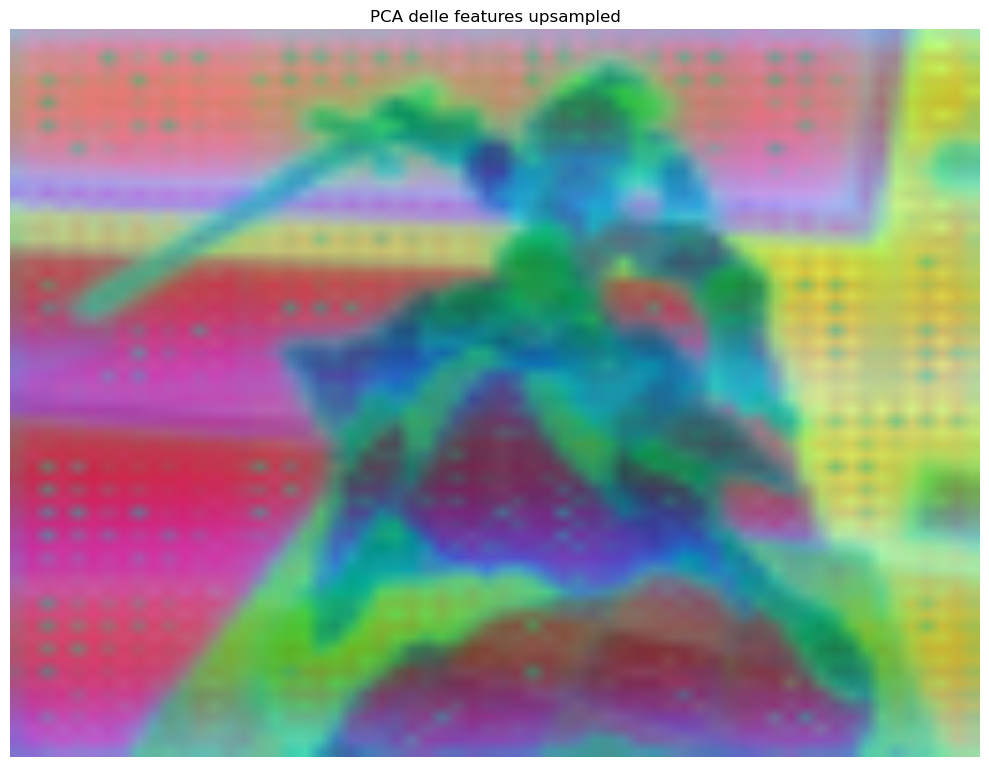

In [15]:
plt.figure(figsize=(10, 8))
plt.imshow(pca_image_up)
plt.title("PCA delle features upsampled")
plt.axis("off")
plt.tight_layout()
plt.show()

[INFO] PCA(1) -> varianza spiegata: 0.1231, cluster: 160, noise: 356
[INFO] PCA(2) -> varianza spiegata: 0.2074, cluster: 50, noise: 1426
[INFO] PCA(3) -> varianza spiegata: 0.2615, cluster: 28, noise: 1425
[INFO] PCA(4) -> varianza spiegata: 0.3127, cluster: 2, noise: 189
[INFO] PCA(5) -> varianza spiegata: 0.3592, cluster: 33, noise: 2014
[INFO] PCA(10) -> varianza spiegata: 0.5193, cluster: 41, noise: 2037
[INFO] PCA(20) -> varianza spiegata: 0.7001, cluster: 50, noise: 1912
[INFO] PCA(50) -> varianza spiegata: 0.8889, cluster: 56, noise: 1725
[INFO] PCA(100) -> varianza spiegata: 0.9675, cluster: 56, noise: 1727


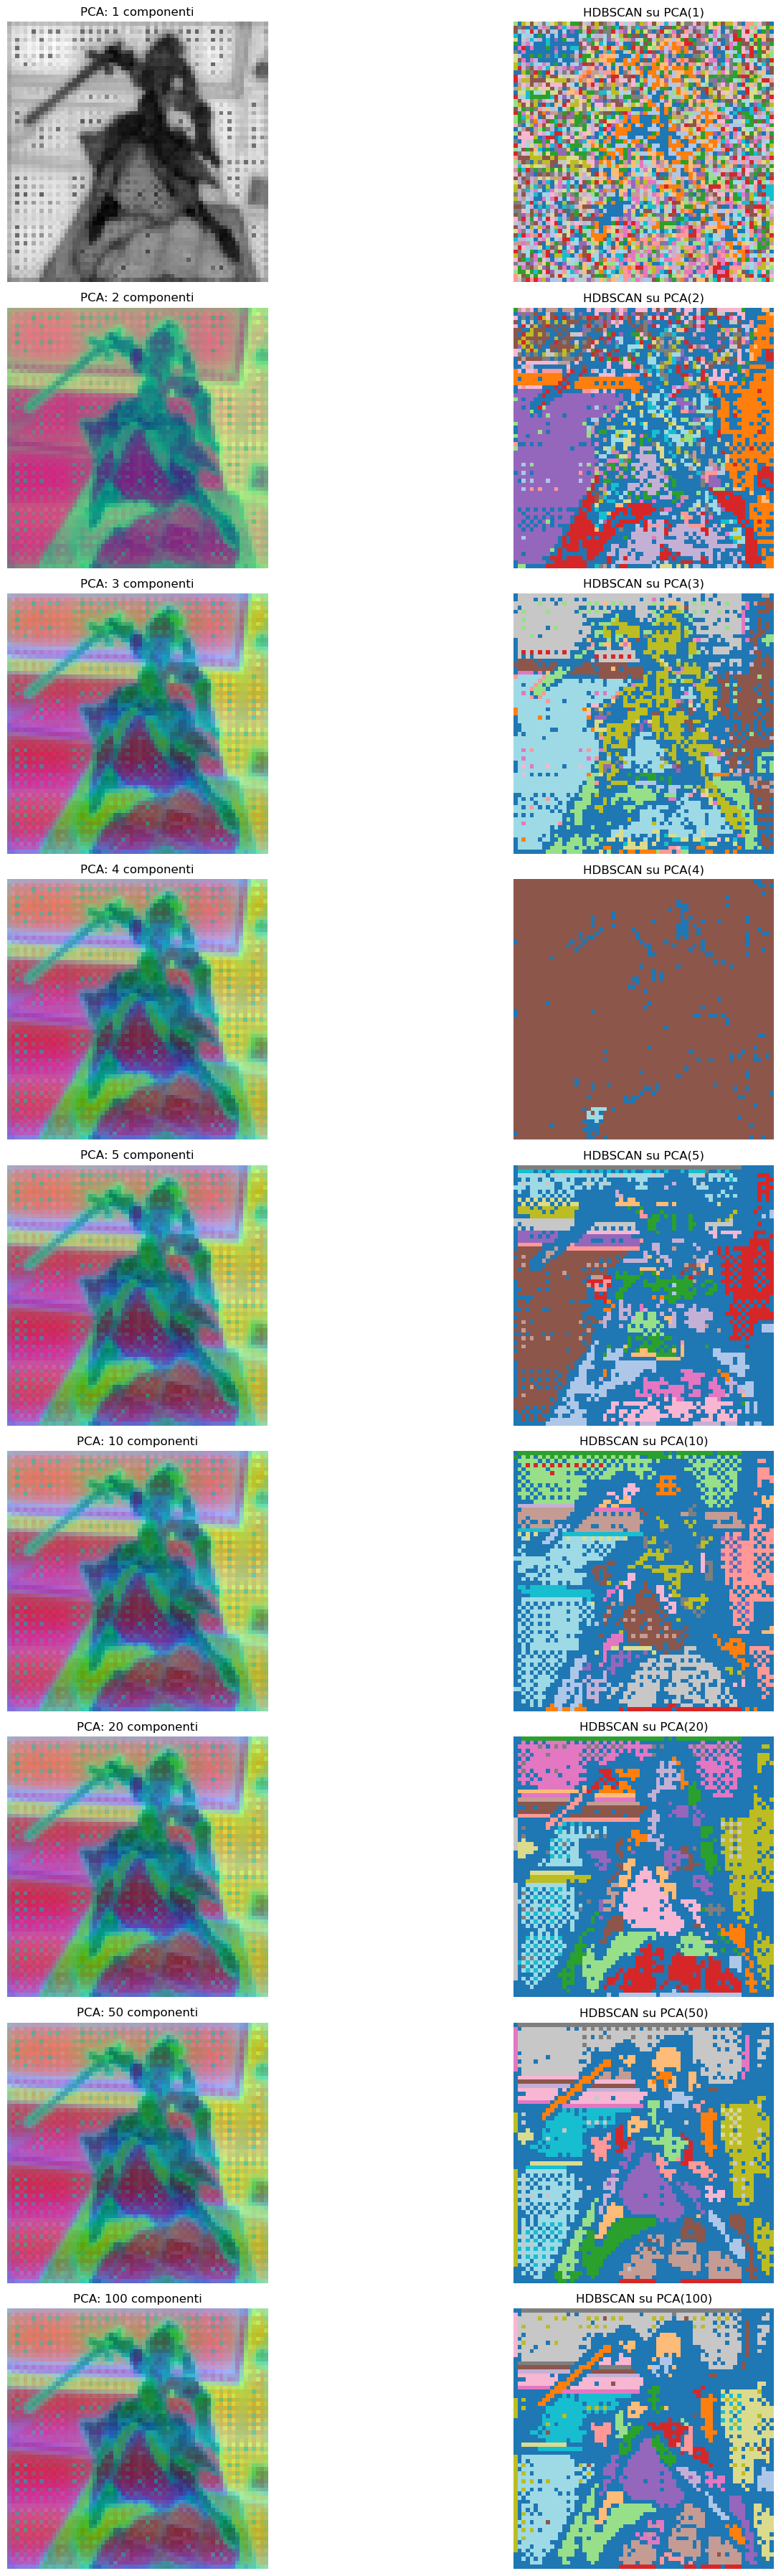

In [14]:
dims = [1, 2, 3, 4, 5, 10, 20, 50, 100]

def normalize01(x):
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def make_vis_image(X_red, h, w):
    if X_red.shape[1] >= 3:
        vis = X_red[:, :3]
    elif X_red.shape[1] == 2:
        vis = np.concatenate([X_red, np.zeros((X_red.shape[0], 1), dtype=X_red.dtype)], axis=1)
    else:
        vis = np.repeat(X_red, 3, axis=1)
    vis = vis.reshape(h, w, 3)
    return normalize01(vis)

fig, axes = plt.subplots(len(dims), 2, figsize=(18, 4 * len(dims)))

for i, n_components in enumerate(dims):
    pca_n = PCA(n_components=n_components)
    X_pca_n = pca_n.fit_transform(X_raw)

    clusterer_n = HDBSCAN(min_cluster_size=10, min_samples=5)
    labels_n = clusterer_n.fit_predict(X_pca_n)
    cluster_map_n = labels_n.reshape(height, width)

    pca_vis_n = make_vis_image(X_pca_n, height, width)

    axes[i, 0].imshow(pca_vis_n)
    axes[i, 0].set_title(f"PCA: {n_components} componenti")
    axes[i, 0].axis("off")

    im = axes[i, 1].imshow(cluster_map_n, cmap="tab20")
    axes[i, 1].set_title(f"HDBSCAN su PCA({n_components})")
    axes[i, 1].axis("off")

    n_clusters = len(set(labels_n)) - (1 if -1 in labels_n else 0)
    n_noise = int(np.sum(labels_n == -1))
    print(f"[INFO] PCA({n_components}) -> varianza spiegata: {pca_n.explained_variance_ratio_.sum():.4f}, "
          f"cluster: {n_clusters}, noise: {n_noise}")

plt.tight_layout()
plt.show()